# GP_CALIBRATION — Macroparticle & grid-resolution calibration for GUINEA-PIG++

Paper-ready figures for the GUINEA-PIG++ luminosity calibration study.
Each figure is rendered inline and saved to `plots/` as both PDF and PNG.

**Figures**
1. Convergence scan — increase each grid parameter and find where `L` converges
2. Refined scan — re-sweep each parameter around the converged region
3. Calibration of the required macroparticle count `n_m^req` vs vertical emittance `ε_y`
4. Required vertical resolution `n_y^req` vs vertical emittance `ε_y`

All four figures estimate the converged luminosity the same way: a weighted fit of `L = L∞ − C/nᵖ`, with a ±5% band centred on the fitted `L∞`.


## Setup

Imports, calibration constants, data loading, and the shared fit / physics helpers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_IN = Path('data/lumi_extracted.csv')

# Nominal calibration point
NOM_NX = 512
NOM_NY = 512
NOM_NZ = 25
NOM_NM = 100_000
NOM_NT = 6
NOM_IM = 2          # integration_method 2 = FFT
NOM_CX, NOM_CY, NOM_CZ = 20.0, 20.0, 3.5
EPS_Y_CAL = 0.008   # nm.rad in CSV units (8 nm.rad)
EPS_X_CAL = 0.9     # µm·µrad
PARTICLES = 0.624
BETA_X = 12.0
BETA_Y = 0.12
SIGMA_Z = 100.0
OFFSET_Y = 0.0

# Canonical 15-seed set — DO NOT substitute. Every data point in this notebook
# is an average across exactly these seeds.
CANONICAL_SEEDS = [100805, 105469, 130471, 135135, 143455, 145992, 153768,
                   159302, 167029, 167815, 286038, 360177, 479728, 527875,
                   733579]

# Source-priority for smart dedup (older `output/` rows can mislabel n_m;
# prefer `output_nm/` when the same (config, seed) appears in both).
SRC_PRIORITY = {'output_nm': 0, 'output_no_pairs': 1, 'output': 2}

print(f'{len(CANONICAL_SEEDS)} canonical seeds')
print(f'Nominal grid: n_x={NOM_NX}, n_y={NOM_NY}, n_z={NOM_NZ}, n_m={NOM_NM}')
print(f'Anchor beam:  ε_y={EPS_Y_CAL*1000} nm.rad, ε_x={EPS_X_CAL} µm·µrad')

15 canonical seeds
Nominal grid: n_x=512, n_y=512, n_z=25, n_m=100000
Anchor beam:  ε_y=8.0 nm.rad, ε_x=0.9 µm·µrad


In [2]:
# ── Output: every figure is shown inline AND written to ./plots as PDF + PNG ──
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

# ±5% convergence band, used by the estimator and calibration cells below.
TOLERANCE_PCT = 5.0

def save_fig(fig, name, dpi=300):
    """Save `fig` to plots/<name>.pdf and plots/<name>.png (tight bbox)."""
    for ext in ('pdf', 'png'):
        fig.savefig(PLOT_DIR / f'{name}.{ext}', bbox_inches='tight', dpi=dpi)
    print(f'Saved: plots/{name}.pdf, plots/{name}.png')


In [3]:
# ── Load CSV; fill omitted-but-nominal columns; restrict to the anchor config ──
df = pd.read_csv(DATA_IN)

num_cols = ['n_x', 'n_y', 'n_z', 'n_m', 'n_t', 'emitt_x', 'emitt_y',
            'beta_x', 'beta_y', 'sigma_z', 'offset_y', 'seed',
            'integration_method', 'cut_x', 'cut_y', 'cut_z',
            'particles', 'lumi_ee']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Older filename conventions omit some parameters. Per project convention,
# treat omitted columns as nominal — smart source-priority dedup below then
# resolves rare conflicts where two rows share (config, seed).
df['n_m']                = df['n_m'].fillna(NOM_NM)
df['n_t']                = df['n_t'].fillna(NOM_NT)
df['integration_method'] = df['integration_method'].fillna(NOM_IM)
df['cut_x']              = df['cut_x'].fillna(NOM_CX)
df['cut_y']              = df['cut_y'].fillna(NOM_CY)
df['cut_z']              = df['cut_z'].fillna(NOM_CZ)
df['offset_y']           = df['offset_y'].fillna(OFFSET_Y)
df['beta_y']             = df['beta_y'].fillna(BETA_Y)
df['source_priority']    = df['source_dir'].map(SRC_PRIORITY).fillna(3).astype(int)

# Drop the deeply pre-asymptotic n_m=10k points from every sweep, plot,
# and fit downstream. Per user spec the lowest n_m kept is 50k.
df = df[df['n_m'] >= 50000].reset_index(drop=True)

# Lock everything except the four grid params we sweep.
fixed = (
    (df['emitt_x'] == EPS_X_CAL) &
    (df['emitt_y'] == EPS_Y_CAL) &
    (df['beta_x']  == BETA_X)    &
    (df['beta_y']  == BETA_Y)    &
    (df['sigma_z'] == SIGMA_Z)   &
    (df['offset_y']== OFFSET_Y)  &
    (df['particles']==PARTICLES) &
    (df['integration_method']==NOM_IM) &
    (df['n_t']     == NOM_NT)    &
    (df['cut_x']   == NOM_CX)    &
    (df['cut_y']   == NOM_CY)    &
    (df['cut_z']   == NOM_CZ)    &
    df['lumi_ee'].notna()        &
    df['seed'].isin(CANONICAL_SEEDS)
)
base = df[fixed].copy()
print(f'Rows at calibration anchor (canonical seeds, nominal cuts/method): {len(base)}')

def sweep_aggregate(sweep_col, holds):
    """Return mean ± SEM of lumi_ee vs `sweep_col`, holding `holds` fixed.
    `holds` is a dict of {col: value}. Dedupe by (sweep_col + holds keys + seed),
    preferring rows from higher-priority source dirs. Drop rows with fewer than
    2 seeds (their std and therefore SEM are undefined and break downstream fits).
    """
    sel = base.copy()
    for col, val in holds.items():
        sel = sel[sel[col] == val]
    group_cols = [sweep_col] + list(holds.keys())
    # smart dedup: lowest priority number wins
    sel = (sel.sort_values('source_priority')
              .drop_duplicates(subset=group_cols + ['seed'], keep='first'))
    g = (sel.groupby(sweep_col)
             .agg(n_seeds=('seed','nunique'),
                  mean_L=('lumi_ee','mean'),
                  std_L =('lumi_ee','std'))
             .reset_index())
    # Per user spec the per-point error is the sample STD of the seeds,
    # not the SEM. The column name `sem_L` is kept so downstream fits and
    # plotting code don't need to change — only the value differs.
    g['sem_L'] = g['std_L']
    g = g[g['n_seeds'] >= 2]
    return g.sort_values(sweep_col).reset_index(drop=True)

L_UNIT = 1e34  # report L in units of 10^34 cm^-2 s^-1

def plot_sweep(g, sweep_col, nominal_val, xlabel, title):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    x = g[sweep_col].values
    y = g['mean_L'].values / L_UNIT
    yerr = g['sem_L'].values / L_UNIT
    ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=3, color='C0',
                ecolor='C0', markersize=6, lw=1.4, label='mean ± STD')
    # annotate n_seeds for any point that isn't exactly 15
    for xi, yi, ns in zip(x, y, g['n_seeds'].values):
        if ns != 15:
            ax.annotate(f'n={ns}', (xi, yi), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=8, color='gray')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda v, _: f'{int(v)}'))
    ax.axvline(nominal_val, color='k', ls=':', lw=1, alpha=0.6,
               label=f'nominal {sweep_col}={nominal_val}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$L$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(loc='best', fontsize=9)
    plt.tight_layout()
    return fig, ax

Rows at calibration anchor (canonical seeds, nominal cuts/method): 1043


In [4]:
# Coarse-scan sweeps: vary one grid parameter at a time about the starting
# operating point (n_x=512, n_y=512, n_z=25, n_m=10^5).
g_nm = sweep_aggregate('n_m', {'n_x': NOM_NX, 'n_y': NOM_NY, 'n_z': NOM_NZ})
g_nz = sweep_aggregate('n_z', {'n_x': NOM_NX, 'n_y': NOM_NY, 'n_m': NOM_NM})
g_nx = sweep_aggregate('n_x', {'n_y': NOM_NY, 'n_z': NOM_NZ, 'n_m': NOM_NM})
g_ny = sweep_aggregate('n_y', {'n_x': NOM_NX, 'n_z': NOM_NZ, 'n_m': NOM_NM})


In [5]:
def fit_Linf_fixed_p(g, n_col, p):
    """Weighted LS fit of L = L_inf - C / n^p with p fixed.
    Linear in (L_inf, C); closed-form solution weighted by 1/SEM^2.
    Returns L_inf, sigma_L_inf, C, sigma_C, chi2_red, n_points.
    """
    n   = g[n_col].values.astype(float)
    L   = g['mean_L'].values.astype(float)
    sem = g['sem_L'].values.astype(float)
    X = np.column_stack([np.ones_like(n), -1.0 / n**p])
    W = 1.0 / sem**2
    XtWX = (X * W[:, None]).T @ X
    XtWy = (X * W[:, None]).T @ L
    beta = np.linalg.solve(XtWX, XtWy)
    cov  = np.linalg.inv(XtWX)
    L_inf, C = beta[0], beta[1]
    resid = (L - (L_inf - C / n**p)) / sem
    dof   = len(L) - 2
    chi2_red = (resid**2).sum() / dof if dof > 0 else np.nan
    return dict(L_inf=L_inf, sigma_L_inf=np.sqrt(cov[0,0]),
                C=C, sigma_C=np.sqrt(cov[1,1]),
                chi2_red=chi2_red, n_points=len(L), p=p)


In [6]:
# Refined-scan operating point (the converged region found by the coarse scan),
# used to re-sweep each grid parameter on a finer set of points.
P2_NM, P2_NZ, P2_NX, P2_NY = 250_000, 64, 512, 512

g_nm_2 = sweep_aggregate('n_m', {'n_x': P2_NX, 'n_y': P2_NY, 'n_z': P2_NZ})
g_nz_2 = sweep_aggregate('n_z', {'n_x': P2_NX, 'n_y': P2_NY, 'n_m': P2_NM})
g_nx_2 = sweep_aggregate('n_x', {'n_y': P2_NY, 'n_z': P2_NZ, 'n_m': P2_NM})
g_ny_2 = sweep_aggregate('n_y', {'n_x': P2_NX, 'n_z': P2_NZ, 'n_m': P2_NM})


In [7]:
# ── (ε_y, n_y) heatmap: relative L gain per n_y doubling, at anchor (n_x=512, n_z=64, n_m=250k).
#    Covers the region we ran sims for: n_y ∈ {64..1024}, ε_y ∈ [0, 20] nm·rad.
#    Overlay: theoretical n_y_req = C_y · √D_y(eps_y) curves (full D_y formula).

# ---------- physical constants & C^3-250 beam parameters ----------
R_E       = 2.8179403262e-15
N_P       = PARTICLES * 1e10
SIGMA_Z_M = SIGMA_Z * 1e-6
GAMMA     = 125e9 / 0.5109989461e6
BETA_X_M  = BETA_X * 1e-3
BETA_Y_M  = BETA_Y * 1e-3
EPS_X_SI  = EPS_X_CAL * 1e-6
SIGMA_X   = np.sqrt(EPS_X_SI * BETA_X_M / GAMMA)

def D_y_full(eps_y_nm):
    """Full disruption parameter, eps_y_nm in nm·rad."""
    eps_y_SI = np.asarray(eps_y_nm) * 1e-9
    sigma_y  = np.sqrt(eps_y_SI * BETA_Y_M / GAMMA)
    return 2.0 * R_E * N_P * SIGMA_Z_M / (GAMMA * sigma_y * (SIGMA_X + sigma_y))

print(f"D_y(8 nm)={D_y_full(8.0):.2f}   D_y(20 nm)={D_y_full(20.0):.2f}   "
      f"D_y(0.5 nm)={D_y_full(0.5):.2f}    σ_x = {SIGMA_X*1e9:.1f} nm")


D_y(8 nm)=34.22   D_y(20 nm)=21.52   D_y(0.5 nm)=137.83    σ_x = 210.1 nm


In [8]:
# ── Theory validation: L vs n_m at 3 emittances (ε_y ∈ {0.5, 8, 20} nm)
#    Tests prediction that C_m is emittance-independent.
#    Anchors: (n_x=512, n_z=64) always; n_y=1024 at ε_y=0.5 (scaled), n_y=512 elsewhere.

def aggregate_at_eps(df, sweep_col, eps_y_csv, holds):
    """Return mean ± SEM of lumi_ee vs `sweep_col` at the given ε_y and held params.
    Queries `df` directly (not `base`) so any ε_y can be selected. Drops rows
    with n_seeds < 2 so SEM is well-defined."""
    sel = df[
        (df['emitt_y'] == eps_y_csv) &
        (df['emitt_x'] == EPS_X_CAL) &
        (df['beta_x']  == BETA_X)    & (df['beta_y']  == BETA_Y) &
        (df['sigma_z'] == SIGMA_Z)   & (df['offset_y']== OFFSET_Y) &
        (df['particles']==PARTICLES) &
        (df['integration_method']==NOM_IM) & (df['n_t']==NOM_NT) &
        (df['cut_x']==NOM_CX) & (df['cut_y']==NOM_CY) & (df['cut_z']==NOM_CZ) &
        df['lumi_ee'].notna() & df['seed'].isin(CANONICAL_SEEDS)
    ].copy()
    for col, val in holds.items():
        sel = sel[sel[col] == val]
    group_cols = [sweep_col] + list(holds.keys())
    sel = (sel.sort_values('source_priority')
              .drop_duplicates(subset=group_cols + ['seed'], keep='first'))
    g = (sel.groupby(sweep_col)
             .agg(n_seeds=('seed','nunique'),
                  mean_L =('lumi_ee','mean'),
                  std_L  =('lumi_ee','std'))
             .reset_index())
    # Per user spec: per-point error is the sample STD of the seeds, not
    # the SEM (column name kept for backward compatibility).
    g['sem_L'] = g['std_L']
    g = g[g['n_seeds'] >= 2]
    return g.sort_values(sweep_col).reset_index(drop=True)


In [9]:
# ── Calibrate δ from L vs n_m fits  (k=3 Richardson, numerically rescaled) ───
# Theory:  n_m^req = C_m · D_y^(δ-1/2) · n_x·n_y·n_z         (eq. nm_req)
#
# Fit form (k=3):
#   L(n_m) = L_inf − C1/(n_m/N₀) − C2/(n_m/N₀)² − C3/(n_m/N₀)³
# where N₀ = 1e6 is a scale used purely to keep the design-matrix columns
# O(1) — without it the matrix at 5–8 points with n_m^3 entries spans 1e10
# in column norms and the 4-parameter LS solve becomes ill-conditioned for
# the already-well-converged emittances (8 / 12 / 20 nm).
#
# n_m^req solved from  Σᵢ Cᵢ/(n_m/N₀)^i = L_inf · tol  (cubic, brentq).
# Uncertainty: σ(log n_m^req) by Monte Carlo over MVN(β, cov_β·max(1, χ²_r)).
# δ regression: weighted log-log linear fit using 1/σ_log² as weights.

from scipy.optimize import brentq

TOL_NM = TOLERANCE_PCT / 100.0   # 0.05
K_RICHARDSON = 3
P_BASE = 1
N_SCALE = 1e6                     # rescale n_m → n_m/N₀ for numerical stability

EPS_CASES_DELTA = [
    (r'$\varepsilon_y = 0.5$ nm', 0.0005, 1024),
    (r'$\varepsilon_y = 1$ nm',   0.001,  1024),
    (r'$\varepsilon_y = 2$ nm',   0.002,   512),
    (r'$\varepsilon_y = 4$ nm',   0.004,   512),
    (r'$\varepsilon_y = 8$ nm',   0.008,   512),
    (r'$\varepsilon_y = 12$ nm',  0.012,   512),
    (r'$\varepsilon_y = 20$ nm',  0.020,   512),
]


# Per-emittance n_m lower bound for the Richardson fits — drops the deep
# sub-asymptotic shot-noise regime where the L_inf − C/n^p form breaks down.
# Applied to both the fit here and the L vs n_m figure.
N_M_MIN_PER_EPS = {
    0.0005: 1_000_000,  # 0.5 nm
    0.001:  1_000_000,  # 1 nm
    0.002:    500_000,  # 2 nm
    0.004:    250_000,  # 4 nm
    # 8 / 12 / 20 nm: no extra filter
}

from scipy.optimize import lsq_linear

def _fit_kterm_core(g, n_col, p, k, n_scale, bounds=None):
    """One pass of weighted LS at k=k. bounds=None → unconstrained,
    bounds=tuple → constrained via lsq_linear."""
    n = g[n_col].values.astype(float) / n_scale
    L = g['mean_L'].values.astype(float)
    e = g['sem_L'].values.astype(float)
    N = len(L)
    if N < k + 1:
        return None
    X = np.column_stack([np.ones_like(n)] + [-1.0 / n**(p * i) for i in range(1, k + 1)])
    sw  = 1.0 / e
    Xw  = X * sw[:, None]
    Lw  = L * sw
    if bounds is None:
        try:
            beta = np.linalg.solve(Xw.T @ Xw, Xw.T @ Lw)
        except np.linalg.LinAlgError:
            return None
    else:
        try:
            beta = lsq_linear(Xw, Lw, bounds=bounds, method='trf', verbose=0).x
        except (ValueError, np.linalg.LinAlgError):
            return None
    resid = (L - X @ beta) / e
    dof   = N - (k + 1)
    chi2r = (resid**2).sum() / dof if dof > 0 else float('nan')
    try:
        cov = np.linalg.inv(Xw.T @ Xw)
    except np.linalg.LinAlgError:
        cov = np.eye(k + 1)
    return dict(beta=beta, cov=cov, chi2_r=chi2r, dof=dof, N=N, n_scale=n_scale)


def fit_kterm_local(g, n_col, p, k, n_scale=N_SCALE):
    """Hybrid k-term weighted LS:
       1. Try UNCONSTRAINED. If the resulting cubic has a positive crossing
          AND no Cᵢ is dramatically negative, keep it (preserves full k=3
          shape information when the data supports it).
       2. Otherwise fall back to CONSTRAINED with Cᵢ ≥ 0 (which always
          gives a defined crossing but may peg some Cᵢ to 0).
       Returns the chosen fit dict with an extra key 'fit_mode'."""
    fit_unc = _fit_kterm_core(g, n_col, p, k, n_scale, bounds=None)
    if fit_unc is not None:
        nm_unc = n_m_req_kterm(fit_unc['beta'], TOL_NM, p, k, n_scale=n_scale)
        # accept unconstrained if cubic has a positive root within the bracket
        if np.isfinite(nm_unc) and nm_unc > 0:
            fit_unc['fit_mode'] = 'unconstrained'
            return fit_unc

    lb = np.array([-np.inf] + [0.0] * k)
    ub = np.array([ np.inf] * (k + 1))
    fit_con = _fit_kterm_core(g, n_col, p, k, n_scale, bounds=(lb, ub))
    if fit_con is not None:
        fit_con['fit_mode'] = 'constrained (Cᵢ≥0)'
    return fit_con


def n_m_req_kterm(beta, tol, p, k, n_scale=N_SCALE):
    """Smallest positive n_m (original units) where Σᵢ Cᵢ/(n/n_scale)^(p·i) = L_inf·tol."""
    L_inf = beta[0]
    Cs    = beta[1:k + 1]
    target = L_inf * tol
    def f(n_norm):
        return sum(Cs[i - 1] / n_norm**(p * i) for i in range(1, k + 1)) - target
    try:
        n_norm_root = brentq(f, 1e-5, 1e5)
        return n_norm_root * n_scale
    except (ValueError, RuntimeError):
        return float('nan')


def mc_sigma_log_n_m_req(beta, cov, chi2_r, tol, p, k,
                          n_scale=N_SCALE, n_samples=2000):
    """MC σ(log n_m^req): draw β ~ MVN(β̂, cov × max(1, χ²_r)), solve cubic, take std."""
    rng   = np.random.default_rng(42)
    scale = max(1.0, chi2_r) if np.isfinite(chi2_r) else 1.0
    try:
        samples = rng.multivariate_normal(beta, cov * scale, size=n_samples)
    except (ValueError, np.linalg.LinAlgError):
        return float('nan')
    nm_reqs = np.array([n_m_req_kterm(s, tol, p, k, n_scale=n_scale) for s in samples])
    good = np.isfinite(nm_reqs) & (nm_reqs > 0)
    if good.sum() < 50:
        return float('nan')
    return float(np.log(nm_reqs[good]).std())


cal_rows = []
for label, ey_csv, ny_a in EPS_CASES_DELTA:
    anchor = {'n_x': 512, 'n_y': ny_a, 'n_z': 64, 'n_m': 250_000}
    holds  = {k: v for k, v in anchor.items() if k != 'n_m'}
    g      = aggregate_at_eps(df, 'n_m', ey_csv, holds)
    nm_min_eps = N_M_MIN_PER_EPS.get(ey_csv, 0)
    if nm_min_eps > 0:
        g = g[g['n_m'] >  nm_min_eps].reset_index(drop=True)
    n_xyz  = anchor['n_x'] * anchor['n_y'] * anchor['n_z']
    Dy     = float(D_y_full(ey_csv * 1e3))

    row = dict(eps_y_nm=ey_csv * 1e3, n_y_anchor=ny_a, n_xyz=n_xyz,
               D_y=round(Dy, 2), n_pts=len(g),
               L_inf=float('nan'), chi2_r=float('nan'), dof=float('nan'),
               fit_mode='-', C1=float('nan'), C2=float('nan'), C3=float('nan'),
               n_m_req=float('nan'), sigma_log_nm=float('nan'),
               n_m_req_per_nxyz=float('nan'),
               status=f'need ≥{K_RICHARDSON + 1} n_m points')

    if len(g) >= K_RICHARDSON + 1:
        fit = fit_kterm_local(g, 'n_m', P_BASE, K_RICHARDSON)
        if fit is None:
            row['status'] = 'fit failed (ill-conditioned)'
        else:
            n_m_req = n_m_req_kterm(fit['beta'], TOL_NM, P_BASE, K_RICHARDSON)
            sigma_log = (mc_sigma_log_n_m_req(fit['beta'], fit['cov'], fit['chi2_r'],
                                              TOL_NM, P_BASE, K_RICHARDSON)
                         if np.isfinite(n_m_req) else float('nan'))
            row.update(L_inf=round(fit['beta'][0] / L_UNIT, 4),
                       chi2_r=(round(fit['chi2_r'], 3)
                               if np.isfinite(fit['chi2_r']) else float('nan')),
                       dof=int(fit['dof']),
                       fit_mode=fit.get('fit_mode', '?'),
                       C1=round(fit['beta'][1] / L_UNIT, 6),
                       C2=round(fit['beta'][2] / L_UNIT, 6),
                       C3=round(fit['beta'][3] / L_UNIT, 6))
            if np.isfinite(n_m_req) and n_m_req > 0:
                row.update(n_m_req=int(round(n_m_req)),
                           sigma_log_nm=(round(sigma_log, 4)
                                         if np.isfinite(sigma_log) else float('nan')),
                           n_m_req_per_nxyz=n_m_req / n_xyz,
                           status='ok (exact fit)' if fit['dof'] == 0 else 'ok')
            else:
                row['status'] = 'cubic has no positive crossing'

    cal_rows.append(row)

cal_df = pd.DataFrame(cal_rows)
print(f'=== Per-ε_y n_m^req from k={K_RICHARDSON} Richardson-fit crossing of ±{TOLERANCE_PCT:.0f}% band ===')
print(cal_df.to_string(index=False))


/sdf/home/l/laithg/miniconda3/envs/warpx-gpu-test/lib/python3.11/site-packages/scipy/optimize/_lsq/trf_linear.py:116: RuntimeWarning: invalid value encountered in multiply
  r_h = p_h + r_h * r_stride
/sdf/home/l/laithg/miniconda3/envs/warpx-gpu-test/lib/python3.11/site-packages/scipy/optimize/_lsq/trf_linear.py:116: RuntimeWarning: invalid value encountered in multiply
  r_h = p_h + r_h * r_stride


=== Per-ε_y n_m^req from k=3 Richardson-fit crossing of ±5% band ===
 eps_y_nm  n_y_anchor    n_xyz    D_y  n_pts  L_inf  chi2_r  dof           fit_mode       C1        C2       C3  n_m_req  sigma_log_nm  n_m_req_per_nxyz status
      0.5        1024 33554432 137.83      7 5.0196   0.462    3      unconstrained 5.285048 -8.278847 4.494199 19405522        0.2782          0.578330     ok
      1.0        1024 33554432  97.36      5 4.0171   0.012    1      unconstrained 3.020679 -5.417373 3.792016 13088713        0.7523          0.390074     ok
      2.0         512 16777216  68.75      6 2.9927   0.028    2      unconstrained 0.734175 -0.584334 0.260416  4047960        0.7708          0.241277     ok
      4.0         512 16777216  48.52      5 2.1652   0.008    1      unconstrained 0.232467 -0.089302 0.012134  1701082        0.7045          0.101392     ok
      8.0         512 16777216  34.22      6 1.4596   1.117    2 constrained (Cᵢ≥0) 0.008812  0.000000 0.000000   120754        0.5

## Figure 1 — Convergence scan

Increase each grid parameter (`n_m`, `n_z`, `n_x`, `n_y`) one at a time and locate the region where the luminosity `L` stops changing. Each panel fits `L = L∞ − C/nᵖ` and shades a ±5% band around the fitted `L∞`.

Saved: plots/convergence_scan.pdf, plots/convergence_scan.png


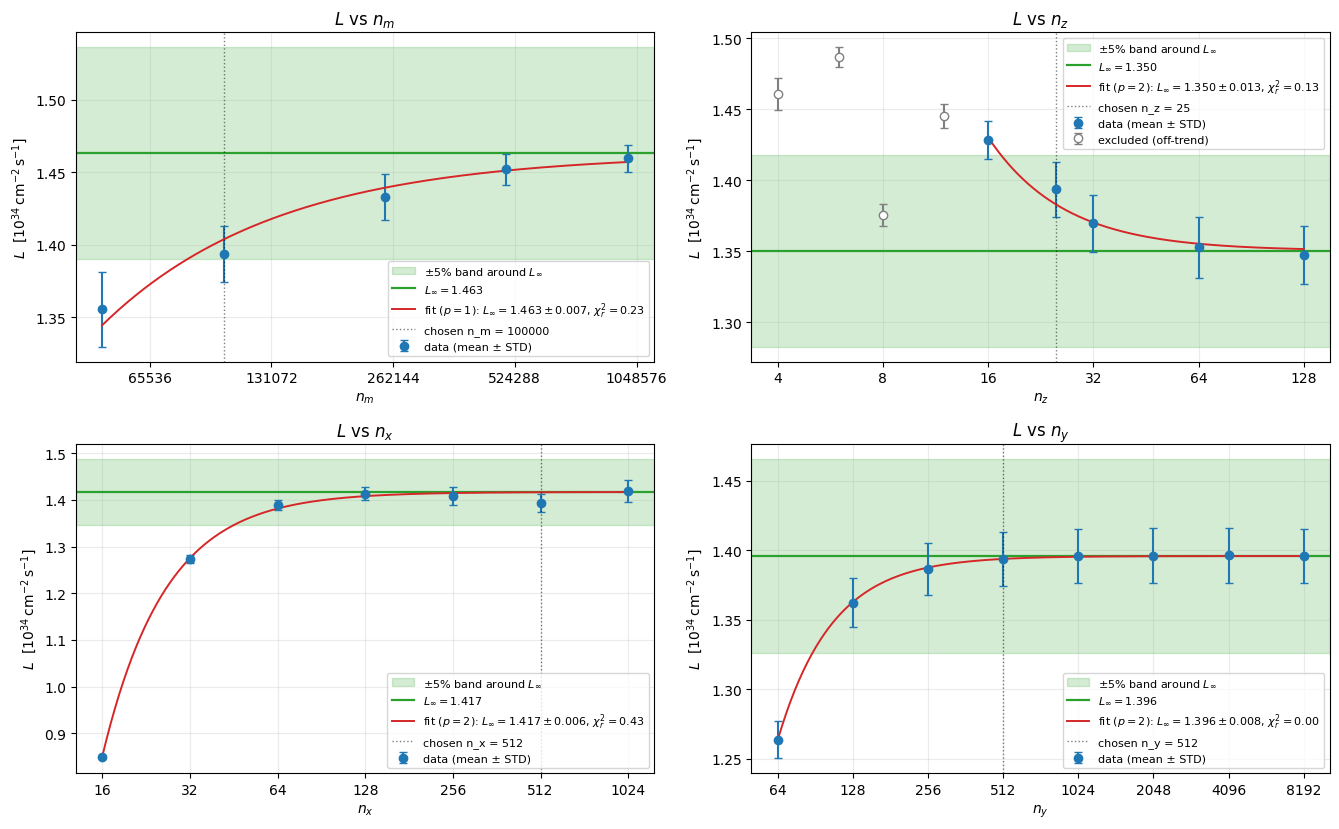

In [10]:
# Convergence scan: increase each grid parameter (n_m, n_z, n_x, n_y) one at a
# time and find the region where the luminosity L stops changing. Each panel fits
# L = L_inf - C/n^p and shades a +/-5% band around the fitted L_inf. Points that
# sit off the asymptotic trend (low-n_z under-sampling) are dropped from the fit
# and shown as open grey markers.
scan = [
    ('n_m', g_nm, 1, NOM_NM, r'$n_m$', set(),         'lower right'),
    ('n_z', g_nz, 2, NOM_NZ, r'$n_z$', {4, 6, 8, 12}, 'upper right'),
    ('n_x', g_nx, 2, NOM_NX, r'$n_x$', set(),         'lower right'),
    ('n_y', g_ny, 2, NOM_NY, r'$n_y$', set(),         'lower right'),
]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4))
for (col, g_all, p, nom, xlbl, drop, loc), ax in zip(scan, axes.flatten()):
    g      = g_all[~g_all[col].isin(drop)].reset_index(drop=True)
    g_drop = g_all[g_all[col].isin(drop)]

    # fit L_inf - C/n^p; the +/-5% band is centred on the fitted L_inf
    fit  = fit_Linf_fixed_p(g, col, p)
    Linf = fit['L_inf'] / L_UNIT
    sig  = fit['sigma_L_inf'] / L_UNIT
    ax.axhspan(Linf * 0.95, Linf * 1.05, color='C2', alpha=0.20,
               label=r'$\pm 5\%$ band around $L_\infty$')
    ax.axhline(Linf, color='C2', lw=1.6, label=fr'$L_\infty = {Linf:.3f}$')

    # data (filled) and off-trend points (open)
    n  = g[col].values
    ax.errorbar(n, g['mean_L'].values / L_UNIT, yerr=g['sem_L'].values / L_UNIT,
                fmt='o', color='C0', ecolor='C0', capsize=3, markersize=6,
                label='data (mean ± STD)')
    if len(g_drop):
        ax.errorbar(g_drop[col].values, g_drop['mean_L'].values / L_UNIT,
                    yerr=g_drop['sem_L'].values / L_UNIT, fmt='o', mfc='white',
                    mec='grey', color='grey', capsize=3, markersize=6,
                    label='excluded (off-trend)')

    # fit curve
    nn   = np.geomspace(n.min(), n.max(), 250)
    Lfit = (fit['L_inf'] - fit['C'] / nn**p) / L_UNIT
    ax.plot(nn, Lfit, '-', color='C3', lw=1.4,
            label=fr"fit ($p={p}$): $L_\infty={Linf:.3f}\pm{sig:.3f}$, "
                  fr"$\chi^2_r={fit['chi2_red']:.2f}$")

    ax.axvline(nom, color='k', ls=':', lw=1, alpha=0.5,
               label=f'chosen {col} = {nom}')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.set_xlabel(xlbl)
    ax.set_ylabel(r'$L$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
    ax.set_title(fr'$L$ vs {xlbl}')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(loc=loc, fontsize=8)

plt.tight_layout()
save_fig(fig, 'convergence_scan')
plt.show()


## Figure 2 — Refined convergence scan

Move to the smallest `n` inside each converged region, then re-sweep each parameter on a finer grid to confirm `L` is flat there. Same fit and ±5% band as Figure 1.

Saved: plots/convergence_scan_refined.pdf, plots/convergence_scan_refined.png


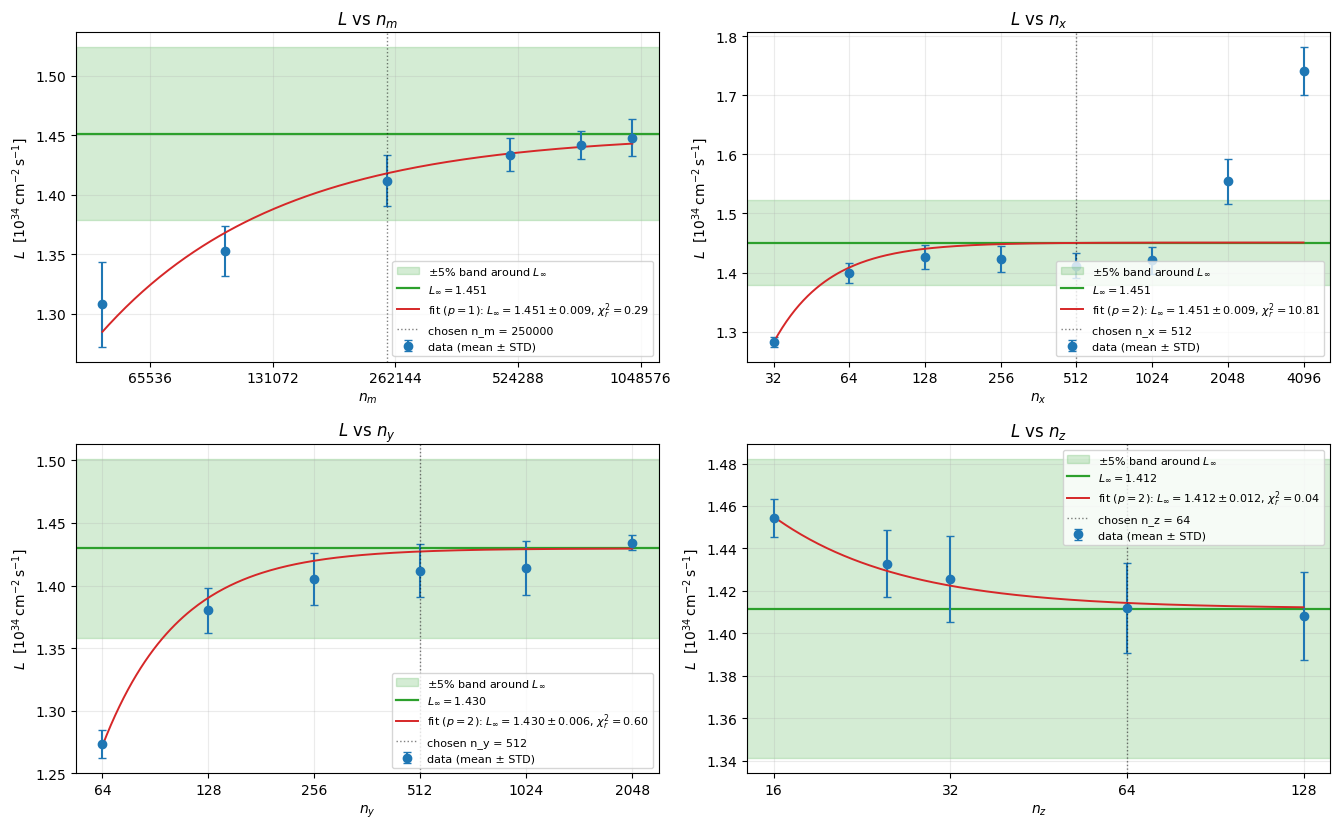

In [11]:
# Refined scan: starting from the smallest n inside each converged region, re-sweep
# every grid parameter on a finer set of points to confirm L is flat there. Same
# estimator as Figure 1: fit L = L_inf - C/n^p with a +/-5% band on the fitted L_inf.
scan_refined = [
    ('n_m', g_nm_2, 1, P2_NM, r'$n_m$', 'lower right'),
    ('n_x', g_nx_2, 2, P2_NX, r'$n_x$', 'lower right'),
    ('n_y', g_ny_2, 2, P2_NY, r'$n_y$', 'lower right'),
    ('n_z', g_nz_2, 2, P2_NZ, r'$n_z$', 'upper right'),
]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4))
for (col, g, p, nom, xlbl, loc), ax in zip(scan_refined, axes.flatten()):
    ax.set_xlabel(xlbl)
    ax.set_ylabel(r'$L$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
    ax.set_title(fr'$L$ vs {xlbl}')
    ax.grid(True, which='both', alpha=0.25)
    if len(g) < 2:
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='grey')
        continue

    fit = fit_Linf_fixed_p(g, col, p) if len(g) >= 3 else None
    if fit is not None and np.isfinite(fit['L_inf']):
        Linf = fit['L_inf'] / L_UNIT
        sig  = fit['sigma_L_inf'] / L_UNIT
    else:
        Linf, sig = g['mean_L'].iloc[-1] / L_UNIT, float('nan')

    ax.axhspan(Linf * 0.95, Linf * 1.05, color='C2', alpha=0.20,
               label=r'$\pm 5\%$ band around $L_\infty$')
    ax.axhline(Linf, color='C2', lw=1.6, label=fr'$L_\infty = {Linf:.3f}$')

    n = g[col].values
    ax.errorbar(n, g['mean_L'].values / L_UNIT, yerr=g['sem_L'].values / L_UNIT,
                fmt='o', color='C0', ecolor='C0', capsize=3, markersize=6,
                label='data (mean ± STD)')

    if fit is not None and np.isfinite(fit['L_inf']):
        nn   = np.geomspace(n.min(), n.max(), 250)
        Lfit = (fit['L_inf'] - fit['C'] / nn**p) / L_UNIT
        ax.plot(nn, Lfit, '-', color='C3', lw=1.4,
                label=fr"fit ($p={p}$): $L_\infty={Linf:.3f}\pm{sig:.3f}$, "
                      fr"$\chi^2_r={fit['chi2_red']:.2f}$")

    ax.axvline(nom, color='k', ls=':', lw=1, alpha=0.5,
               label=f'chosen {col} = {nom}')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.legend(loc=loc, fontsize=8)

plt.tight_layout()
save_fig(fig, 'convergence_scan_refined')
plt.show()


## Figure 3 — Macroparticle calibration: `n_m^req` vs `ε_y`

Left: `L` vs `n_m` for a range of vertical emittances, with the fitted `n_m^req` (the `n_m` at which `L` first reaches the ±5% band). Right: the resulting `n_m^req/(n_x n_y n_z)` vs the disruption parameter `D_y(ε_y)`, fitted to a power law.

/sdf/home/l/laithg/miniconda3/envs/warpx-gpu-test/lib/python3.11/site-packages/scipy/optimize/_lsq/trf_linear.py:116: RuntimeWarning: invalid value encountered in multiply
  r_h = p_h + r_h * r_stride
/sdf/home/l/laithg/miniconda3/envs/warpx-gpu-test/lib/python3.11/site-packages/scipy/optimize/_lsq/trf_linear.py:116: RuntimeWarning: invalid value encountered in multiply
  r_h = p_h + r_h * r_stride


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/L_vs_nm.pdf, plots/L_vs_nm.png


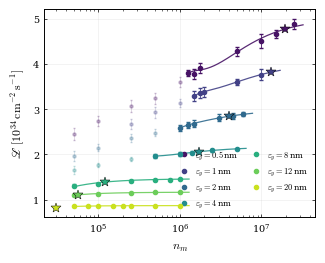

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/nm_req_calibration.pdf, plots/nm_req_calibration.png


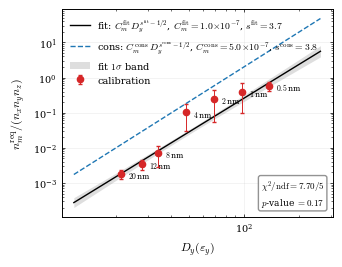


  fitted s^fit = 3.701 ± 0.199     C_m^fit = 1.014e-07 ± 8.02e-08     χ²/ndf = 7.70/5   p = 0.174


In [12]:
# Macroparticle calibration: the required macroparticle count n_m^req as a
# function of vertical emittance e_y.
#   Left  panel: L vs n_m for each e_y, with the fitted n_m^req (the n_m at
#                which L reaches the +/-5% band, marked with a star).
#   Right panel: n_m^req/(n_x n_y n_z) vs the disruption parameter D_y(e_y),
#                fitted to the power law C_m * D_y^(s-1/2).

from pathlib import Path
import matplotlib.ticker as mticker

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

prl_style_local = {
    'font.family':      'serif',
    'font.size':        8,
    'axes.labelsize':   8.5,
    'axes.titlesize':   8,
    'legend.fontsize':  6.5,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'axes.linewidth':   0.7,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.4,
    'lines.linewidth':  1.0,
    'lines.markersize': 3.2,
    'text.usetex':      False,
    'mathtext.fontset': 'cm',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
}

# ────────────────────── Figure 1: L vs n_m ──────────────────────────────
with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))
    colors = plt.cm.viridis(np.linspace(0.05, 0.92, len(EPS_CASES_DELTA)))

    for (label, ey_csv, ny_a), color in zip(EPS_CASES_DELTA, colors):
        holds = {'n_x': 512, 'n_y': ny_a, 'n_z': 64}
        g_all = aggregate_at_eps(df, 'n_m', ey_csv, holds)
        nm_min_eps = N_M_MIN_PER_EPS.get(ey_csv, 0)
        if nm_min_eps > 0:
            g_used     = g_all[g_all['n_m'] >  nm_min_eps].reset_index(drop=True)
            g_excluded = g_all[g_all['n_m'] <= nm_min_eps].reset_index(drop=True)
        else:
            g_used     = g_all
            g_excluded = g_all.iloc[0:0]
        if len(g_used) < 2:
            continue

        eps_lbl = label.replace(r'$\varepsilon_y = ', '').replace('$', '').replace(' nm', '')

        # excluded points (low opacity)
        if len(g_excluded):
            ax.errorbar(g_excluded['n_m'].values,
                        g_excluded['mean_L'].values / L_UNIT,
                        yerr=g_excluded['sem_L'].values / L_UNIT,
                        fmt='o', color=color, ecolor=color, alpha=0.28,
                        capsize=0.8, elinewidth=0.4, lw=0, ms=2.2,
                        zorder=3)

        # fit
        if len(g_used) >= K_RICHARDSON + 1:
            fit = fit_kterm_local(g_used, 'n_m', P_BASE, K_RICHARDSON)
            if fit is not None:
                beta = fit['beta']
                n_m_req = n_m_req_kterm(beta, TOL_NM, P_BASE, K_RICHARDSON)
                top = max(g_used['n_m'].max(),
                          n_m_req if np.isfinite(n_m_req) else 0) * 1.3
                nn_used = np.geomspace(g_used['n_m'].min(), top, 250)
                Lfit = (beta[0] - sum(beta[i] / (nn_used / N_SCALE)**(P_BASE*i)
                                      for i in range(1, K_RICHARDSON+1))) / L_UNIT
                ok = Lfit > 0
                ax.plot(nn_used[ok], Lfit[ok], '-', color=color,
                        lw=0.9, alpha=0.9, zorder=4)
                if np.isfinite(n_m_req) and n_m_req > 0:
                    L_at_req = beta[0] * (1.0 - TOL_NM) / L_UNIT
                    ax.plot([n_m_req], [L_at_req], '*', color=color, ms=7,
                            markeredgecolor='black', markeredgewidth=0.35,
                            zorder=10)

        # used data points (small)
        ax.errorbar(g_used['n_m'].values,
                    g_used['mean_L'].values / L_UNIT,
                    yerr=g_used['sem_L'].values / L_UNIT,
                    fmt='o', color=color, ecolor=color,
                    capsize=1.2, elinewidth=0.6, lw=0, ms=3.0,
                    zorder=5)

    ax.set_xscale('log', base=10)
    ax.set_xlabel(r'$n_m$')
    ax.set_ylabel(r'$\mathscr{L}\ [10^{34}\,\mathrm{cm^{-2}\,s^{-1}}]$')
    ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                   top=True, right=True)
    # compact in-axes legend with ε_y values only
    handles, labels = [], []
    for (label, ey_csv, ny_a), color in zip(EPS_CASES_DELTA, colors):
        eps_lbl = label.replace(r'$\varepsilon_y = ', '').replace('$', '').replace(' nm', '')
        handles.append(plt.Line2D([0], [0], marker='o', color=color, lw=0, markersize=3))
        labels.append(fr'$\varepsilon_y={eps_lbl}\,$nm')
    ax.legend(handles, labels, loc='lower right', frameon=False,
              fontsize=6.0, ncol=2, columnspacing=1.0,
              handletextpad=0.4, borderaxespad=0.4)
    save_fig(fig, 'L_vs_nm')
    plt.show()


# ────────────────── Figure 2: n_m^req / (n_xyz) vs D_y ─────────────────
with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))

    ok = cal_df[cal_df['n_m_req_per_nxyz'].notna()].copy()
    if len(ok) >= 2:
        logD  = np.log(ok['D_y'].values)
        logNm = np.log(ok['n_m_req_per_nxyz'].values)
        sig_log = ok['sigma_log_nm'].values.astype(float)
        finite  = np.isfinite(sig_log) & (sig_log > 0)
        sig_fill = float(np.median(sig_log[finite])) if finite.any() else 0.1
        sig_log  = np.where(finite, sig_log, sig_fill)
        sig_log  = np.maximum(sig_log, 1e-3)
        w  = 1.0 / sig_log**2
        sw, sxw, syw = w.sum(), (w * logD).sum(), (w * logNm).sum()
        sxxw, sxyw   = (w * logD**2).sum(), (w * logD * logNm).sum()
        det          = sw * sxxw - sxw**2
        intercept    = (sxxw * syw - sxw * sxyw) / det
        slope        = (sw   * sxyw - sxw * syw)   / det
        var_slope    = sw   / det
        s_param      = slope + 0.5         # renamed from δ to s for the paper
        sigma_s      = float(np.sqrt(var_slope))
        var_int      = sxxw / det
        cov_int_slope = -sxw / det               # covariance term for band
        sigma_int    = float(np.sqrt(var_int))
        C_m          = float(np.exp(intercept))
        sigma_C_m    = float(C_m * sigma_int)   # δC_m = C_m · δ(log C_m)
        # ── χ²/ndf and p-value from the weighted LS residuals ──
        pred_log     = intercept + slope * logD
        resid_log    = logNm - pred_log
        chi2_val     = float(((resid_log / sig_log)**2).sum())
        ndf_val      = len(ok) - 2
        from scipy.stats import chi2 as _chi2_dist
        p_value      = float(1.0 - _chi2_dist.cdf(chi2_val, ndf_val)) if ndf_val > 0 else float('nan')

        # data
        yerr_lin = ok['n_m_req_per_nxyz'].values * sig_log
        ax.errorbar(ok['D_y'].values, ok['n_m_req_per_nxyz'].values,
                    yerr=yerr_lin, fmt='o', ms=4.5, color='C3',
                    capsize=1.5, ecolor='C3', elinewidth=0.7, lw=0,
                    zorder=5, label='calibration')

        # power-law line — fitted
        dx = np.geomspace(ok['D_y'].min() * 0.55, ok['D_y'].max() * 1.9, 80)
        # Standard form (1 digit + 1 decimal × power of 10) for C_m display
        import math as _math
        def _stdform(x):
            if not (x and _math.isfinite(x)): return ('0', 0)
            e = int(_math.floor(_math.log10(abs(x))))
            m = x / 10**e
            return (f'{m:.1f}', e)
        Cm_mant, Cm_exp = _stdform(C_m)
        s_disp = round(s_param, 1)         # 1 decimal on s
        ax.plot(dx, C_m * dx**(s_param - 0.5), '-', color='k', lw=1.0, zorder=4,
                label=(fr'fit: $C_m^{{\mathrm{{fit}}}}\,D_y^{{s^{{\mathrm{{fit}}}}-1/2}}$, '
                       fr'$C_m^{{\mathrm{{fit}}}}={Cm_mant}\!\times\!10^{{{Cm_exp}}}$, '
                       fr'$s^{{\mathrm{{fit}}}}={s_disp}$'))
        # conservative target — user-specified C_m, s for safe-side production
        C_M_CONS, S_CONS = 5.0e-7, 3.8
        ax.plot(dx, C_M_CONS * dx**(S_CONS - 0.5), '--', color='C0', lw=1.0, zorder=4,
                label=(fr'cons: $C_m^{{\mathrm{{cons}}}}\,D_y^{{s^{{\mathrm{{cons}}}}-1/2}}$, '
                       fr'$C_m^{{\mathrm{{cons}}}}={_stdform(C_M_CONS)[0]}\!\times\!10^{{{_stdform(C_M_CONS)[1]}}}$, '
                       fr'$s^{{\mathrm{{cons}}}}={S_CONS:.1f}$'))

        # ── 1σ uncertainty band on the fit line (joint cov of intercept+slope) ──
        logdx = np.log(dx)
        # Var[log y(x)] = Var(int) + 2 x Cov(int,slope) + x² Var(slope)
        var_pred_log = var_int + 2.0 * logdx * cov_int_slope + (logdx**2) * var_slope
        sigma_pred_log = np.sqrt(np.maximum(var_pred_log, 0.0))
        y_centre = C_m * dx**(s_param - 0.5)
        y_upper  = y_centre * np.exp(sigma_pred_log)
        y_lower  = y_centre * np.exp(-sigma_pred_log)
        ax.fill_between(dx, y_lower, y_upper, color='k', alpha=0.13, lw=0,
                        zorder=3, label=fr'fit $1\sigma$ band')

        # ── annotate χ²/ndf + p-value in the bottom-right corner ──
        ax.text(0.97, 0.04,
                fr'$\chi^2/\mathrm{{ndf}} = {chi2_val:.2f}/{ndf_val}$' '\n'
                fr'$p$-value $= {p_value:.2f}$',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=6.5, linespacing=1.2,
                bbox=dict(facecolor='white', alpha=0.85,
                          edgecolor='0.5', boxstyle='round,pad=0.25'))

        # per-point ε_y annotation
        for _, r in ok.iterrows():
            ax.annotate(fr"${r['eps_y_nm']:g}\,$nm",
                        (r['D_y'], r['n_m_req_per_nxyz']),
                        textcoords='offset points', xytext=(5, -3),
                        fontsize=5.6)

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'$D_y(\varepsilon_y)$')
        ax.set_ylabel(r'$n_m^{\mathrm{req}}/(n_x n_y n_z)$')
        ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                       top=True, right=True)
        ax.legend(loc='upper left', frameon=False, fontsize=7)

        save_fig(fig, 'nm_req_calibration')
        plt.show()
        print(f'\n  fitted s^fit = {s_param:.3f} ± {sigma_s:.3f}     '
              f'C_m^fit = {C_m:.3e} ± {sigma_C_m:.2e}     '
              f'χ²/ndf = {chi2_val:.2f}/{ndf_val}   p = {p_value:.3f}')
    else:
        print('not enough calibration points for the s plot')

## Figure 4 — Vertical-resolution calibration: `n_y^req` vs `ε_y`

Figure A: `L` vs (`n_m`, `n_x`, `n_z`) across three emittances, each with an `L = L∞ − C/nᵖ` fit and ±5% band. Figure B: relative `L` gain per `n_y` doubling over `(ε_y, n_y)`, with the theoretical required-resolution curves overlaid.

_(These two panels will be revised before the final version.)_

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/L_vs_n_by_emittance_9panel.pdf, plots/L_vs_n_by_emittance_9panel.png


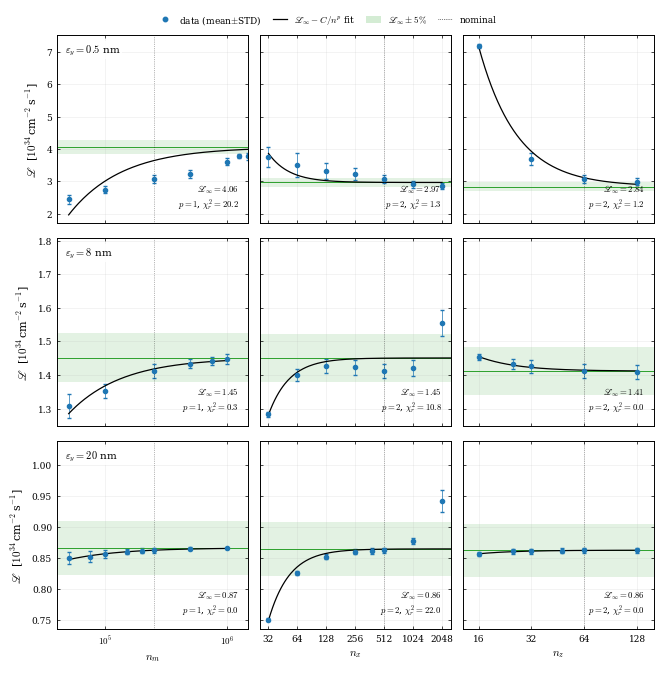

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/ny_req_heatmap.pdf, plots/ny_req_heatmap.png


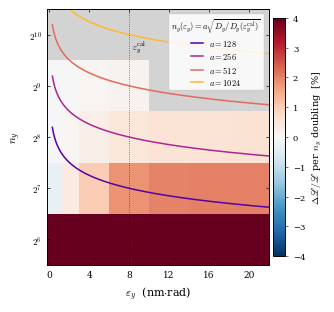

In [13]:
# Vertical-resolution calibration: how fine the transverse grid must be vs e_y.
#   Figure A: L vs (n_m, n_x, n_z) for three emittances, each fitted with
#             L = L_inf - C/n^p and a +/-5% band on the fitted L_inf.
#   Figure B: relative L gain per n_y doubling over (e_y, n_y), with the
#             theoretical required-resolution curves n_y(e_y) overlaid.

from pathlib import Path
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

prl_style = {
    'font.family':      'serif',
    'font.size':        8,
    'axes.labelsize':   8,
    'axes.titlesize':   8,
    'legend.fontsize':  6.5,
    'xtick.labelsize':  6.5,
    'ytick.labelsize':  6.5,
    'axes.linewidth':   0.7,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.4,
    'lines.linewidth':  1.0,
    'lines.markersize': 3.2,
    'text.usetex':      False,
    'mathtext.fontset': 'cm',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
}

EPS_CASES_PRL = [
    ('0.5', 0.0005, 1024),
    ('8',   0.008,   512),
    ('20',  0.020,   512),
]
SWEEPS_PRL = [
    # (col_name, p, x-label, xlim, tick-list, tick-labels)
    # xlim padded ~25% beyond first/last data value on the log scale.
    ('n_m', 1, r'$n_m$', (4.0e4, 1.5e6),
        [100000, 1000000],
        [r'$10^5$', r'$10^6$']),
    ('n_x', 2, r'$n_x$', (26, 2560),
        [32, 64, 128, 256, 512, 1024, 2048],
        ['32', '64', '128', '256', '512', '1024', '2048']),
    ('n_z', 2, r'$n_z$', (13, 160),
        [16, 32, 64, 128],
        ['16', '32', '64', '128']),
]


# =============================================================================
# Figure A — 9-panel theory test (rows = ε_y, cols = sweep parameter)
# =============================================================================
with plt.rc_context(prl_style):
    fig, axes = plt.subplots(3, 3, figsize=(6.75, 6.75),
                             sharex='col', sharey='row',
                             gridspec_kw=dict(hspace=0.08, wspace=0.06))

    for row, (eps_lbl, eps_csv, ny_a) in enumerate(EPS_CASES_PRL):
        for col, (sw, p, xlbl, xlim, tloc, tlab) in enumerate(SWEEPS_PRL):
            ax = axes[row, col]
            anchor = {'n_x': 512, 'n_y': ny_a, 'n_z': 64, 'n_m': 250000}
            holds  = {k: v for k, v in anchor.items() if k != sw}
            g = aggregate_at_eps(df, sw, eps_csv, holds)

            if len(g) >= 2:
                # For the n_m sweep, completely drop the n_m=10000 point from both
                # the fit and the plot — it sits in the catastrophic-shot-noise
                # regime, not the asymptotic 1/n_m tail assumed by the fit.
                if sw == 'n_m':
                    g = g[g[sw].values > 10000].reset_index(drop=True)
                n  = g[sw].values
                L  = g['mean_L'].values / L_UNIT
                ye = g['sem_L'].values  / L_UNIT
                ax.errorbar(n, L, yerr=ye, fmt='o', color='C0',
                            ecolor='C0', capsize=1.2, elinewidth=0.5,
                            markersize=3.0, lw=0)
                if len(g) >= 3:
                    fit = fit_Linf_fixed_p(g, sw, p)
                    if np.isfinite(fit['L_inf']):
                        Li  = fit['L_inf']       / L_UNIT
                        sig = fit['sigma_L_inf'] / L_UNIT
                        ax.axhspan(Li*0.95, Li*1.05,
                                   color='C2', alpha=0.13, lw=0)
                        ax.axhline(Li, color='C2', lw=0.7)
                        nn   = np.geomspace(n.min(), n.max(), 200)
                        Lfit = (fit['L_inf'] - fit['C']/nn**p) / L_UNIT
                        ax.plot(nn, Lfit, '-', color='k', lw=0.9)
                        ax.text(0.95, 0.06,
                                fr'$\mathscr{{L}}_\infty={Li:.2f}$' + '\n'
                                fr'$p={p}$, $\chi^2_r={fit["chi2_red"]:.1f}$',
                                transform=ax.transAxes,
                                ha='right', va='bottom', fontsize=6.3,
                                linespacing=1.1)
                ax.axvline(anchor[sw], color='k', ls=':', lw=0.5, alpha=0.55)
            else:
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                        ha='center', va='center', color='grey', fontsize=7)

            ax.set_xscale('log', base=10)
            ax.set_xlim(*xlim)
            ax.xaxis.set_major_locator(mticker.FixedLocator(tloc))
            ax.xaxis.set_major_formatter(mticker.FixedFormatter(tlab))
            ax.xaxis.set_minor_locator(mticker.NullLocator())
            ax.tick_params(direction='in', length=2.5, width=0.5,
                           top=True, right=True)
            ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                           top=True, right=True)

            if col == 0:
                ax.text(0.04, 0.96, fr'$\varepsilon_y = {eps_lbl}$ nm',
                        transform=ax.transAxes, ha='left', va='top',
                        fontsize=7.5,
                        bbox=dict(facecolor='white', alpha=0.85,
                                  edgecolor='none', pad=1.5))
                ax.set_ylabel(r'$\mathscr{L}$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
            if row == 2:
                ax.set_xlabel(xlbl)

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='C0', lw=0, markersize=3.2,
                   label=r'data (mean$\pm$STD)'),
        plt.Line2D([0], [0], color='k', lw=0.9, label=r'$\mathscr{L}_\infty-C/n^p$ fit'),
        mpatches.Patch(facecolor='C2', alpha=0.20,
                       label=r'$\mathscr{L}_\infty \pm 5\%$'),
        plt.Line2D([0], [0], color='k', ls=':', lw=0.5, label='nominal'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.0), frameon=False,
               handlelength=1.6, columnspacing=1.2)

    fig.subplots_adjust(left=0.10, right=0.985, top=0.955, bottom=0.075)
    save_fig(fig, 'L_vs_n_by_emittance_9panel', dpi=300)
    plt.show()


# =============================================================================
# Figure B — dL/dn_y heatmap, 1-column square
# Cells centered on the actual sampled ε_y values {0.5, 2, 4, 8, 12, 16, 20},
# with edges at midpoints (outer edges symmetric) so the heatmap tiles the
# (ε_y, n_y) grid completely once all sims land. Colormap clipped to [-1, 4]
# %: no significant negative gradients are physically expected.
# =============================================================================
with plt.rc_context(prl_style):
    fig, ax = plt.subplots(figsize=(3.375, 3.20))

    ny_bins_b = np.array([64, 128, 256, 512, 1024])
    log2_ny_b = np.log2(ny_bins_b).astype(int)

    eps_centers_b = np.array([0.5, 2.0, 4.0, 8.0, 12.0, 16.0, 20.0])
    mids   = 0.5 * (eps_centers_b[:-1] + eps_centers_b[1:])
    e_low  = eps_centers_b[0]  - (mids[0]  - eps_centers_b[0])
    e_high = eps_centers_b[-1] + (eps_centers_b[-1] - mids[-1])
    eps_edges_b = np.concatenate([[e_low], mids, [e_high]])

    sel_b = df[
        (df['emitt_x']==EPS_X_CAL) & (df['beta_x']==BETA_X) & (df['beta_y']==BETA_Y) &
        (df['sigma_z']==SIGMA_Z) & (df['offset_y']==OFFSET_Y) & (df['particles']==PARTICLES) &
        (df['integration_method']==NOM_IM) & (df['n_t']==NOM_NT) &
        (df['cut_x']==NOM_CX) & (df['cut_y']==NOM_CY) & (df['cut_z']==NOM_CZ) &
        df['lumi_ee'].notna() & df['seed'].isin(CANONICAL_SEEDS) &
        (df['n_x']==P2_NX) & (df['n_z']==P2_NZ) & (df['n_m']==P2_NM) &
        df['n_y'].isin(ny_bins_b)
    ].copy()
    sel_b['eps_y_nm'] = (sel_b['emitt_y']*1000).round(3)
    dedup_b = (sel_b.sort_values('source_priority')
                    .drop_duplicates(subset=['eps_y_nm','n_y','seed'], keep='first'))
    agg_b = (dedup_b.groupby(['eps_y_nm','n_y'])
                    .agg(n_seeds=('seed','nunique'), mean_L=('lumi_ee','mean'))
                    .reset_index())
    agg_b = agg_b[agg_b['n_seeds'] >= 2]

    L_grid_b = np.full((len(ny_bins_b), len(eps_centers_b)), np.nan)
    for _, r in agg_b.iterrows():
        diffs = np.abs(eps_centers_b - r['eps_y_nm'])
        j = int(np.argmin(diffs))
        if diffs[j] > 0.05:
            continue  # only fill cells whose center matches a measured ε_y
        i = int(np.where(ny_bins_b == int(r['n_y']))[0][0])
        L_grid_b[i, j] = r['mean_L']

    pct_b = np.full_like(L_grid_b, np.nan)
    for j in range(L_grid_b.shape[1]):
        for i in range(L_grid_b.shape[0]-1):
            if np.isfinite(L_grid_b[i,j]) and np.isfinite(L_grid_b[i+1,j]):
                pct_b[i,j] = 100.0 * (L_grid_b[i+1,j] - L_grid_b[i,j]) / L_grid_b[i,j]

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='lightgrey')
    y_edges_pc = np.concatenate([log2_ny_b - 0.5, [log2_ny_b[-1] + 0.5]])
    X_pc, Y_pc = np.meshgrid(eps_edges_b, y_edges_pc)
    mesh = ax.pcolormesh(X_pc, Y_pc, pct_b, cmap=cmap, vmin=-4, vmax=4,
                         shading='flat', rasterized=True)
    cb = fig.colorbar(mesh, ax=ax, pad=0.02, fraction=0.05)
    cb.set_label(r'$\Delta\mathscr{L}/\mathscr{L}$ per $n_y$ doubling  [%]',
                 fontsize=7)
    cb.ax.tick_params(labelsize=6, length=2, width=0.4)

    # iso-C_y lines
    eps_smooth_b = np.linspace(max(0.3, e_low), e_high, 400)
    EPS_Y_A      = 8.0
    D_y_a        = D_y_full(EPS_Y_A)
    anchors_b    = [128, 256, 512, 1024]
    line_colors  = plt.cm.plasma(np.linspace(0.15, 0.85, len(anchors_b)))
    for c, a in zip(line_colors, anchors_b):
        line = a * np.sqrt(D_y_full(eps_smooth_b) / D_y_a)
        log2_line = np.log2(line)
        keep = (log2_line >= log2_ny_b[0] - 0.5) & (log2_line <= log2_ny_b[-1] + 0.5)
        ax.plot(eps_smooth_b[keep], log2_line[keep], '-',
                lw=1.1, color=c, label=fr'$a={a}$')

    ax.axvline(EPS_Y_A, color='k', ls=':', lw=0.6, alpha=0.6)
    ax.text(EPS_Y_A + 0.3, log2_ny_b[-1] - 0.1,
            r'$\varepsilon_y^{\rm cal}$', fontsize=6.5, ha='left', va='top')

    ax.set_xlim(e_low, e_high)
    ax.set_ylim(log2_ny_b[0] - 0.5, log2_ny_b[-1] + 0.5)
    ax.set_xticks([0, 4, 8, 12, 16, 20])
    ax.set_yticks(log2_ny_b)
    ax.set_yticklabels([f'$2^{{{k}}}$' for k in log2_ny_b])
    ax.set_xlabel(r'$\varepsilon_y$  (nm$\cdot$rad)')
    ax.set_ylabel(r'$n_y$')
    ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
    ax.legend(loc='upper right', fontsize=6.0, frameon=True,
              framealpha=0.85, handlelength=1.4, labelspacing=0.3,
              title=r'$n_y(\varepsilon_y)=a\sqrt{D_y/D_y(\varepsilon_y^{\rm cal})}$',
              title_fontsize=6.0)
    ax.grid(False)

    fig.tight_layout()
    save_fig(fig, 'ny_req_heatmap', dpi=300)
    plt.show()
